# Linear Regression

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("Advertising.csv", index_col=0)

In [4]:
data.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [5]:
data.shape

(200, 4)

In [6]:
data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [7]:
import matplotlib.pyplot as plt

{'whiskers': [<matplotlib.lines.Line2D at 0x1075676ead0>,
 'caps': [<matplotlib.lines.Line2D at 0x1075676ed50>,
 'boxes': [<matplotlib.lines.Line2D at 0x1075668e990>],
 'medians': [<matplotlib.lines.Line2D at 0x1075676efd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1075676f110>],
 'means': []}

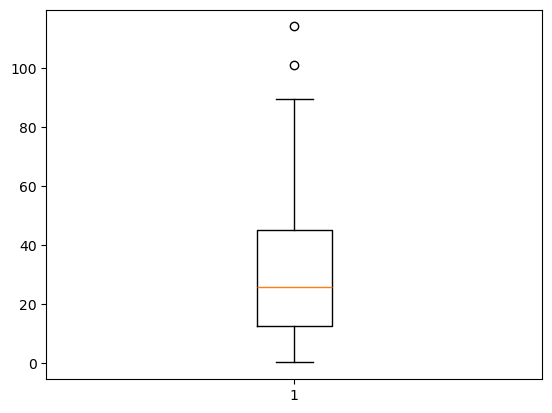

In [8]:
plt.boxplot(data["Newspaper"])

In [9]:
import seaborn as sns

<Axes: >

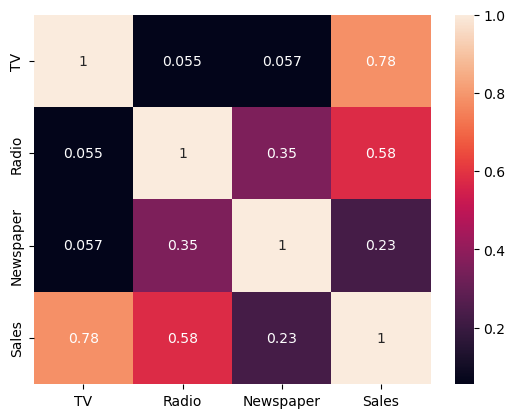

In [10]:
sns.heatmap(data.corr(), annot=True)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x = data[["TV", "Radio", "Newspaper"]]
y = data["Sales"]

In [13]:
x.head()

,TV,Radio,Newspaper
1,230.1,37.8,69.2
2,44.5,39.3,45.1
3,17.2,45.9,69.3
4,151.5,41.3,58.5
5,180.8,10.8,58.4


In [14]:
y.head

<bound method NDFrame.head of 1      22.1
2      10.4
3       9.3
4      18.5
5      12.9
       ... 
196     7.6
197     9.7
198    12.8
199    25.5
200    13.4
Name: Sales, Length: 200, dtype: float64>

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [16]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
print('Beta values: ', model.coef_)
print('Beta Zero value: ', model.intercept_)

Beta values:  [ 0.04787496  0.18672313 -0.00191207]
Beta Zero value:  2.710180001947448


In [20]:
data.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [21]:
# y = b0 + b1x1 + b2x2 + b3x3 ... bnxn

yy = 2.5864331672508882 + (0.04682119 * 230.1) + (0.18849753 * 37.8) + (0.00148238 * 69.2)

In [22]:
yy

20.58777631625089

In [23]:
y_pred = model.predict(x_test)

In [24]:
x_test.head

<bound method NDFrame.head of         TV  Radio  Newspaper
45    25.1   25.7       43.3
158  149.8    1.3       24.3
119  125.7   36.9       79.2
189  286.0   13.9        3.7
63   239.3   15.5       27.3
105  238.2   34.3        5.3
50    66.9   11.7       36.8
179  276.7    2.3       23.7
49   227.2   15.8       49.9
90   109.8   47.8       51.4
180  165.6   10.0       17.6
182  218.5    5.4       27.4
109   13.1    0.4       25.6
110  255.4   26.9        5.5
34   265.6   20.0        0.3
48   239.9   41.5       18.5
28   240.1   16.7       22.9
115   78.2   46.8       34.5
92    28.6    1.5       33.0
94   250.9   36.5       72.3
169  215.4   23.6       57.6
114  209.6   20.6       10.7
153  197.6   23.3       14.2
145   96.2   14.8       38.9
157   93.9   43.5       50.5
20   147.3   23.9       19.1
151  280.7   13.9       37.0
135   36.9   38.6       65.6
24   228.3   16.9       26.2
35    95.7    1.4        7.4
144  104.6    5.7       34.4
106  137.9   46.4       59.0
163  188.4   

In [25]:
x_test["actual_sales"] = y_test
x_test["predicted_sales"] = y_pred
print(x_test)

        TV  Radio  Newspaper  actual_sales  predicted_sales
45    25.1   25.7       43.3           8.5         8.627834
158  149.8    1.3       24.3          10.1        10.078126
119  125.7   36.9       79.2          15.9        15.466710
189  286.0   13.9        3.7          15.9        18.990795
63   239.3   15.5       27.3          15.7        17.008667
105  238.2   34.3        5.3          20.7        20.508465
50    66.9   11.7       36.8           9.7         8.027311
179  276.7    2.3       23.7          11.8        16.341329
49   227.2   15.8       49.9          14.8        16.442184
90   109.8   47.8       51.4          16.7        16.793936
180  165.6   10.0       17.6          12.6        12.471852
182  218.5    5.4       27.4          12.2        14.126773
109   13.1    0.4       25.6           5.3         3.363082
110  255.4   26.9        5.5          19.8        19.949781
34   265.6   20.0        0.3          17.4        19.159658
48   239.9   41.5       18.5          23

In [26]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)

In [27]:
print(rmse)

1.573113367778592


In [28]:
import joblib
joblib.dump(model,"linearRegression.pkl")

['linearRegression.pkl']

In [29]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
